Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
Classes: ['Healthy', 'IDA']
Epoch 1/100 | Train Loss: 0.4684 | Val Loss: 0.5202 | *** Best model saved ***
Epoch 2/100 | Train Loss: 0.1853 | Val Loss: 0.4322 | *** Best model saved ***
Epoch 3/100 | Train Loss: 0.0724 | Val Loss: 0.3737 | *** Best model saved ***
Epoch 4/100 | Train Loss: 0.0273 | Val Loss: 0.5088
Epoch 5/100 | Train Loss: 0.0346 | Val Loss: 0.5834
Epoch 6/100 | Train Loss: 0.0289 | Val Loss: 1.2946
Epoch 7/100 | Train Loss: 0.0178 | Val Loss: 1.7267
Epoch 8/100 | Train Loss: 0.0091 | Val Loss: 1.0682
Epoch 9/100 | Train Loss: 0.0091 | Val Loss: 0.6594
Epoch 10/100 | Train Loss: 0.0053 | Val Loss: 0.4167
Epoch 11/100 | Train Loss: 0.0061 | Val Loss: 0.3617 | *** Best model saved ***
Epoch 12/100 | Train Loss: 0.0039 | Val Loss: 0.3623
Epoch 13/100 | Train Loss: 0.0076 | Val Loss: 0.4285
Epoch 14/100 | Train Loss: 0.0029 | 

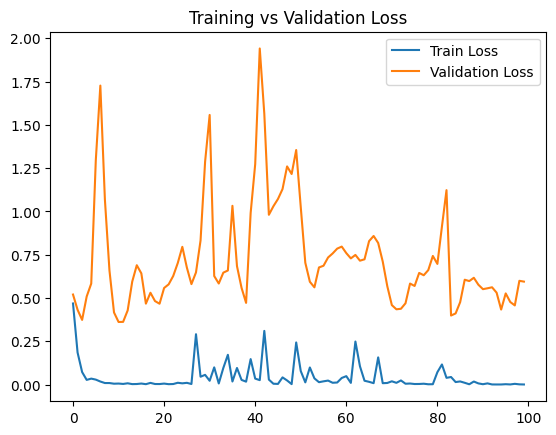

In [15]:
# ============================================================
# ResNet50 for Iron Deficiency Anemia Cell Classification
# Classes:
# Pencil, Microcytosis, Hypochromia, Anisocytosis
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from google.colab import drive
import matplotlib.pyplot as plt
import numpy as np
import os

# ------------------------------------------------------------
# Mount Google Drive
# ------------------------------------------------------------
drive.mount('/content/drive')

# ------------------------------------------------------------
# Dataset Path
# ------------------------------------------------------------
DATASET_PATH = "/content/drive/MyDrive/IDASrilankanDataset/Resnet50"

train_dir = os.path.join(DATASET_PATH, "train")
valid_dir = os.path.join(DATASET_PATH, "valid")
test_dir  = os.path.join(DATASET_PATH, "test")

# ------------------------------------------------------------
# Hyperparameters
# ------------------------------------------------------------
BATCH_SIZE = 32
EPOCHS = 100
LR = 0.0001
IMG_SIZE = 224

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ------------------------------------------------------------
# Image Transformations
# ------------------------------------------------------------
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
valid_dataset = datasets.ImageFolder(valid_dir, transform=test_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)

# ------------------------------------------------------------
# Load ResNet50 Pretrained Model
# ------------------------------------------------------------
model = models.resnet50(pretrained=True)

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(DEVICE)

# ------------------------------------------------------------
# Loss and Optimizer
# ------------------------------------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# ------------------------------------------------------------
# Training Loop (saves best model based on validation loss)
# ------------------------------------------------------------
train_losses = []
valid_losses = []

BEST_MODEL_PATH = "/content/drive/MyDrive/IDASrilankanDataset/Resnet50ResNet50_IDA_Best.pt"
best_val_loss = float('inf')

for epoch in range(EPOCHS):

    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in valid_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

    val_loss = val_loss / len(valid_loader)
    valid_losses.append(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | *** Best model saved ***")
    else:
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

print(f"\nBest model saved at: {BEST_MODEL_PATH} (Val Loss: {best_val_loss:.4f})")

# Load best model weights for evaluation
model.load_state_dict(torch.load(BEST_MODEL_PATH))
print("Loaded best model weights for evaluation.")

# ------------------------------------------------------------
# Plot Loss Curve
# ------------------------------------------------------------
plt.plot(train_losses, label="Train Loss")
plt.plot(valid_losses, label="Validation Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [16]:
# ============================================================
# Evaluate Train, Validation, and Test Accuracy
# ============================================================

def evaluate_accuracy(model, dataloader, device, source_class_to_idx=None, target_class_to_idx=None):
    model.eval()
    correct = 0
    total = 0

    # Build a label remapping if the dataset has mismatched class indices
    remap = None
    if source_class_to_idx and target_class_to_idx:
        remap = {}
        for cls_name, src_idx in source_class_to_idx.items():
            if cls_name in target_class_to_idx:
                remap[src_idx] = target_class_to_idx[cls_name]

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            if remap:
                labels = torch.tensor([remap[l.item()] for l in labels])
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

train_acc = evaluate_accuracy(model, train_loader, DEVICE)
valid_acc = evaluate_accuracy(model, valid_loader, DEVICE)
test_acc  = evaluate_accuracy(model, test_loader, DEVICE,
                              source_class_to_idx=test_dataset.class_to_idx,
                              target_class_to_idx=train_dataset.class_to_idx)

print(f"Train Accuracy:      {train_acc:.2f}%")
print(f"Validation Accuracy: {valid_acc:.2f}%")
print(f"Test Accuracy:       {test_acc:.2f}%")
print()
print(f"NOTE: Test set only has {len(test_dataset)} images from class(es): {list(test_dataset.class_to_idx.keys())}")
print(f"      Train classes: {list(train_dataset.class_to_idx.keys())}")
print(f"      Test labels were remapped to match training class indices.")

Train Accuracy:      100.00%
Validation Accuracy: 92.31%
Test Accuracy:       83.33%

NOTE: Test set only has 6 images from class(es): ['IDA']
      Train classes: ['Healthy', 'IDA']
      Test labels were remapped to match training class indices.
